In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List
import random

In [3]:
class AgentState(TypedDict):
    name:str
    number:List[int]
    counter:int

In [4]:
def greeting_node(state:AgentState)->AgentState:
    """Greeting node which says hi to a person"""
    state['name']=f"Hi there, {state['name']}. We will start the game"
    state['counter']=0
    return state

def random_state(state:AgentState)->AgentState:
    """Generate number (random) between 0 and 10"""
    state['number'].append(random.randint(0,10))
    state['counter']+=1
    return state

def should_continue(state:AgentState)-> str:
    """function to decide what to do next"""
    if state['counter']<5:
        print(f"Enter loop, {state['counter']}")
        return 'loop'
    else:
        print(f"Exit loop, {state['counter']}")
        return 'exit'

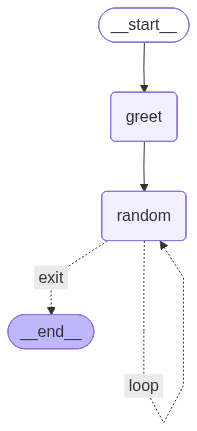

In [5]:
graph=StateGraph(AgentState)
graph.add_node("greet", greeting_node)
graph.add_node("random", random_state)

graph.add_edge(START, "greet")
graph.add_edge("greet", "random")

graph.add_conditional_edges(
    "random",
    should_continue,
    {
        'loop':"random",
        'exit':END
    }
)

graph.add_edge("random", END)
bot=graph.compile()
bot



In [29]:
input_state={
    "name":"Manoj",
    "number":[]
}

response=bot.invoke(input_state)
print(response)

Enter loop, 1
Enter loop, 2
Enter loop, 3
Enter loop, 4
Exit loop, 5
{'name': 'Hi there, Manoj. We will start the game', 'number': [5, 6, 8, 8, 4], 'counter': 5}
